<a href="https://colab.research.google.com/github/RonithJSalian18/Space-Derbis-Identification/blob/main/cv_analysis_oneimg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Image Shape: (512, 512, 3)
Resized Shape: (128, 128, 3)
Grayscale Shape: (128, 128)
Feature Vector Length: 34596

Converted to NumPy Arrays
X shape: (1, 34596)
y shape: (1,)

Sample Feature Values (starting at first non-zero index 135):
[0.62554324 0.         0.62554324 0.         0.46625241 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.35805744 0.        ]


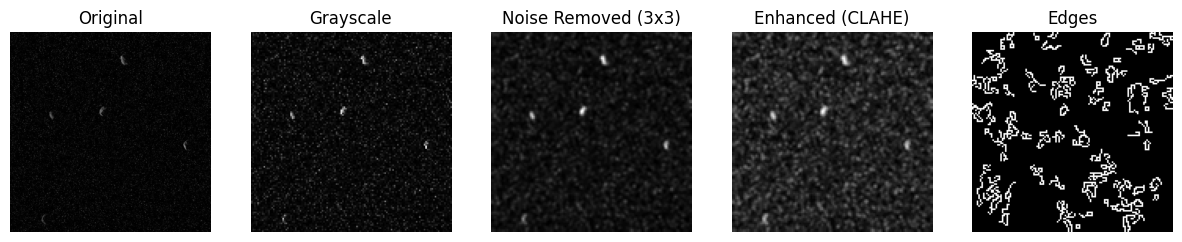

In [ ]:
# ==========================================
# SPACE DEBRIS CV PIPELINE (TEST ONE IMAGE)
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog

# ==============================
# 1. Image Path
# ==============================

image_path = "0.jpg"

image = cv2.imread(image_path)

print("Original Image Shape:", image.shape)


# ==============================
# 2. CV Preprocessing
# ==============================

# Resize
resized = cv2.resize(image,(128,128))
print("Resized Shape:", resized.shape)

# Grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
print("Grayscale Shape:", gray.shape)

# Noise Removal (Adjusted to 3x3 for less aggressive blurring)
denoised = cv2.GaussianBlur(gray,(3,3),0)

# Improved Image Enhancement (Using CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(denoised)

# Edge Detection
edges = cv2.Canny(enhanced,50,150)


# ==============================
# 3. Feature Extraction (HOG)
# ==============================

# Increased resolution to 4x4 for better debris detail
features = hog(
    edges,
    orientations=9,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2),
    visualize=False
)

print("Feature Vector Length:", len(features))


# ==============================
# 4. Convert to NumPy Arrays
# ==============================

data = []
labels = []

data.append(features)

# Example label (1 = debris)
labels.append(1)

X = np.array(data)
y = np.array(labels)

print("\nConverted to NumPy Arrays")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Improved verification: Find first non-zero indices
active_indices = np.where(X[0] > 0)[0]
if len(active_indices) > 0:
    start = active_indices[0]
    print(f"\nSample Feature Values (starting at first non-zero index {start}):")
    print(X[0][start : start + 20])
else:
    print("\nWarning: All features are zero. Check your edge detection.")


# ==============================
# 5. Show CV Processing Steps
# ==============================

plt.figure(figsize=(15,5))

plt.subplot(1,5,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,5,2)
plt.title("Grayscale")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(1,5,3)
plt.title("Noise Removed (3x3)")
plt.imshow(denoised, cmap="gray")
plt.axis("off")

plt.subplot(1,5,4)
plt.title("Enhanced (CLAHE)")
plt.imshow(enhanced, cmap="gray")
plt.axis("off")

plt.subplot(1,5,5)
plt.title("Edges")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.show()

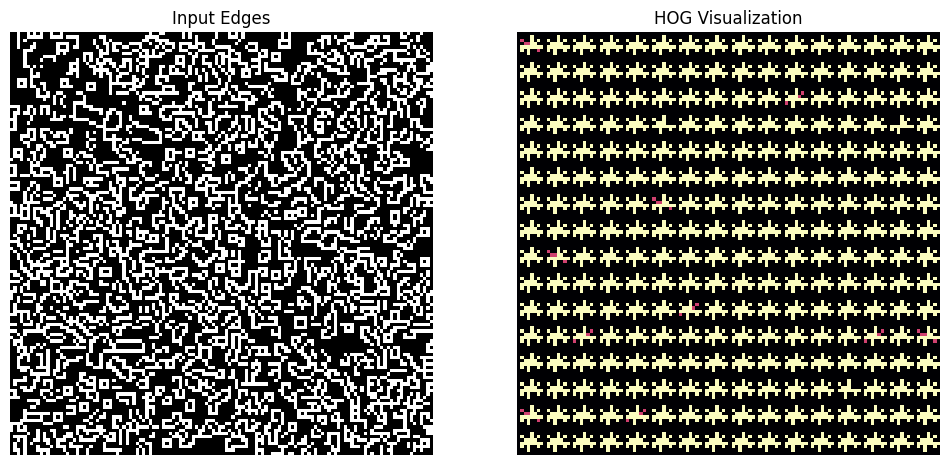

Total features: 8100
Non-zero features: 3588


In [ ]:
#Analysis for feature extraction

from skimage import exposure

# Re-run HOG with visualization enabled
features_viz, hog_image = hog(
    edges,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True
)

# Rescale intensity for better visualization
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Input Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("HOG Visualization")
plt.imshow(hog_image_rescaled, cmap='magma')
plt.axis('off')

plt.show()

# Check if there are any non-zero values in the entire vector
non_zero_count = np.count_nonzero(features_viz)
print(f"Total features: {len(features_viz)}")
print(f"Non-zero features: {non_zero_count}")
if non_zero_count == 0:
    print("WARNING: The feature vector is entirely empty (all zeros).")

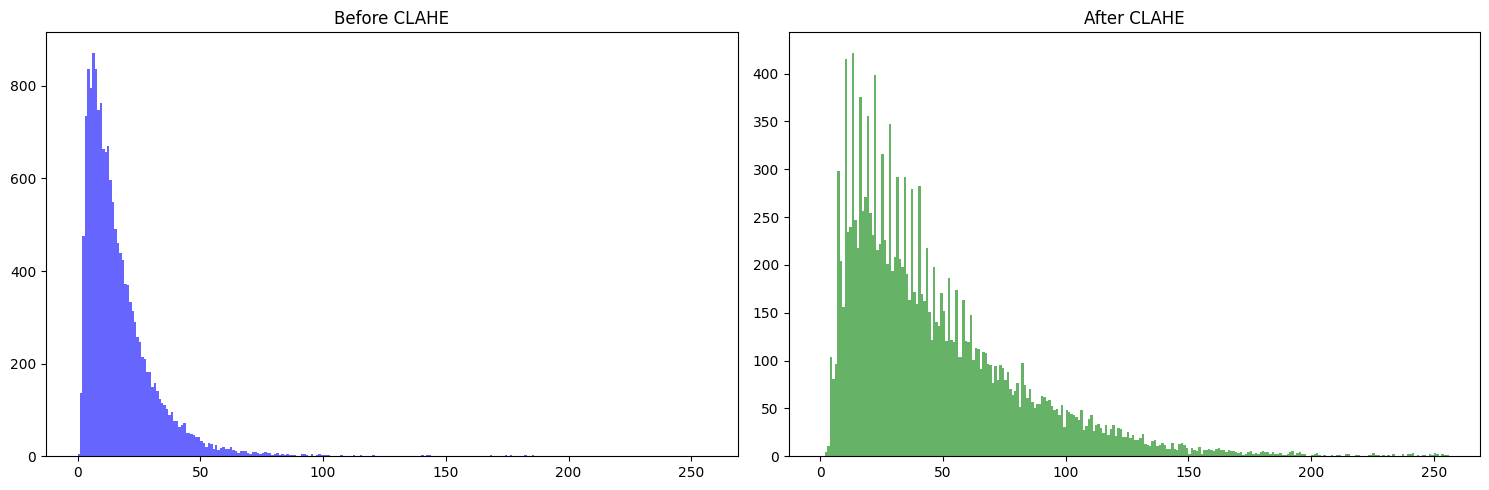

Denoised Mean: 16.71 -> Enhanced Mean: 46.37


In [ ]:
#Analysis for enhancement

import matplotlib.pyplot as plt

# ANALYSIS: CLAHE Enhancement Verification
# CLAHE should spread the histogram (Contrast Stretching) without blowing out the dark background.
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
# Updated range to keyword argument to avoid DeprecationWarning
plt.hist(denoised.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.6, label='Denoised')
plt.title('Before CLAHE')

plt.subplot(1, 2, 2)
# Updated range to keyword argument to avoid DeprecationWarning
plt.hist(enhanced.ravel(), bins=256, range=[0, 256], color='green', alpha=0.6, label='Enhanced')
plt.title('After CLAHE')

plt.tight_layout()
plt.show()

# We look for a significant increase in 'Mean' intensity while keeping 'Min' near 0
print(f"Denoised Mean: {denoised.mean():.2f} -> Enhanced Mean: {enhanced.mean():.2f}")

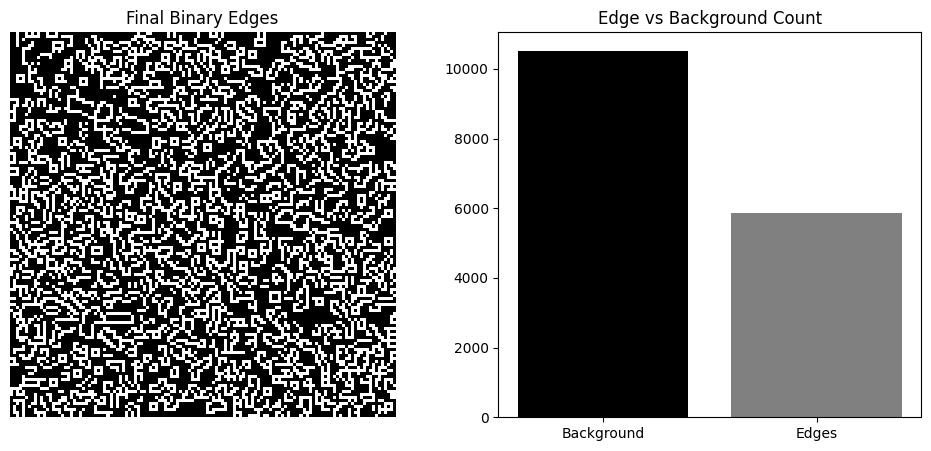

Edge Density: 35.75% (Ideal for debris is usually 1-15%)


In [ ]:
#Analysis for Edge detection

import numpy as np
import matplotlib.pyplot as plt

# ANALYSIS: Edge Density & Quality
# Edge density tells us how much of the image is considered 'structure'.
# Too high (>40%) might mean we are picking up sensor noise.
edge_density = (np.sum(edges == 255) / edges.size) * 100

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Final Binary Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Edge vs Background Count")
plt.bar(['Background', 'Edges'], [np.sum(edges==0), np.sum(edges==255)], color=['black', 'gray'])

plt.show()

print(f"Edge Density: {edge_density:.2f}% (Ideal for debris is usually 1-15%)")

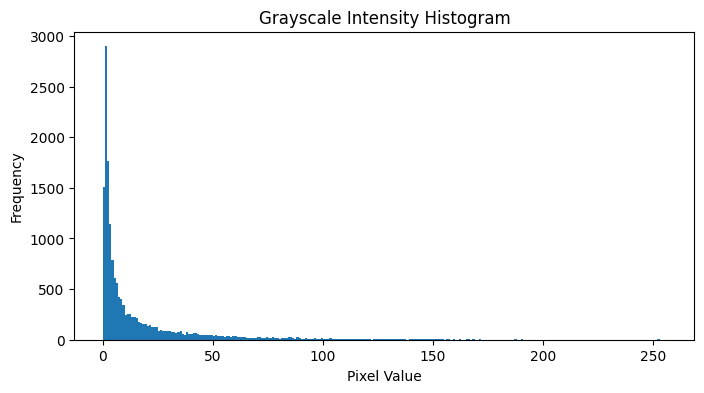

Min intensity: 0
Max intensity: 254
Mean intensity: 16.70


In [ ]:
#Analysis for Grayscale

import matplotlib.pyplot as plt

# ANALYSIS: Grayscale Intensity Distribution
# This histogram helps verify if the image conversion preserved enough contrast.
# A massive spike at 0 is expected for space images (background),
# but we look for a 'tail' of higher values which represent the debris.
plt.figure(figsize=(8, 4))
# Updated range to keyword argument to avoid DeprecationWarning
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.title('Grayscale Intensity Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

# Statistics to check for 'clipping' (data loss at 0 or 255)
print(f"Min intensity: {gray.min()}")
print(f"Max intensity: {gray.max()}")
print(f"Mean intensity: {gray.mean():.2f}")

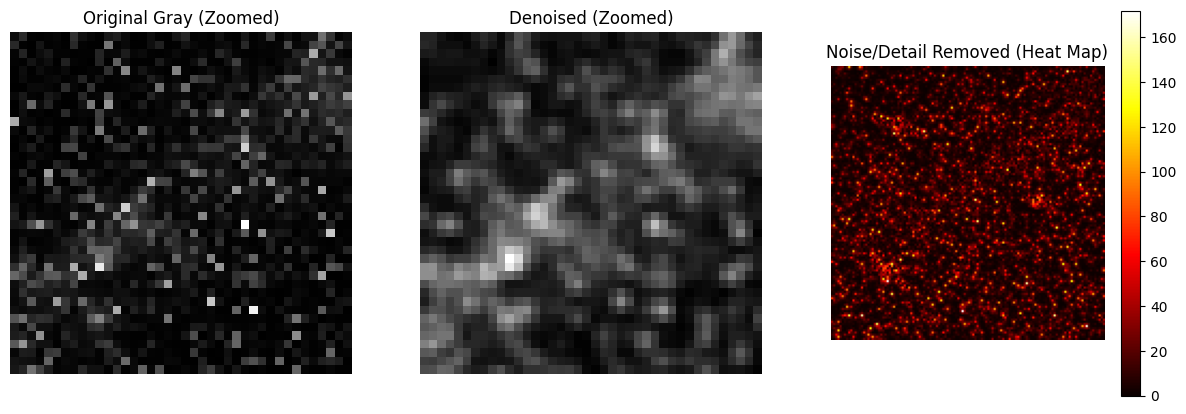

Mean change per pixel: 12.6893
Max change in a pixel: 172


In [ ]:
#Analysis for Noise removal

import numpy as np
import matplotlib.pyplot as plt

# ANALYSIS: Noise Removal Effectiveness
# We subtract the denoised image from the original to see exactly what was filtered out.
# Bright spots in the 'Heat Map' indicate structural edges that might have been blurred.
noise_removed = cv2.absdiff(gray, denoised)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Gray (Zoomed)")
plt.imshow(gray[40:80, 40:80], cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Denoised (Zoomed)")
plt.imshow(denoised[40:80, 40:80], cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Noise/Detail Removed (Heat Map)")
plt.imshow(noise_removed, cmap='hot')
plt.colorbar()
plt.axis('off')

plt.show()

# High 'Mean change' suggests the blur kernel is too large (e.g. 5x5 vs 3x3)
print(f"Mean change per pixel: {np.mean(noise_removed):.4f}")
print(f"Max change in a pixel: {np.max(noise_removed)}")